# CSC 406 Artificial Intelligence — Indigenous Language AI Benchmark

## Group 06: Gbagyi

**Course:** CSC 406 - Artificial Intelligence  
**Group Members:** Yusuf Aminu Abdullahi (team lead) and the GitHub handles listed in `team_plan.md`; full names, student IDs, and emails must be confirmed by the group before submission.  
**Language:** Gbagyi (Gbagyi-Nkwa)  
**Retrieval date for the committed corpus:** 2026-09-04

This notebook uses direct HTTP retrieval of public Gbagyi New Testament chapter pages from STEP Bible. It does not use a pre-tokenized Hugging Face, Kaggle, or published research dataset. The source text remains attributed to the copyright holder; this corpus is prepared for the course exercise and the source URLs are retained in every raw record.

The notebook is intentionally executable from the repository root. The raw and processed files are created under the paths required by the assignment.


## Part 1 — Data collection and provenance

The scraper discovers the chapter URLs from the public version index, retrieves each chapter with `requests`, extracts only the Gbagyi verse spans with BeautifulSoup, and writes one JSON object per verse. A request failure is recorded and does not silently become data. Re-running the notebook refreshes the corpus only when the raw file is absent; call `scrape_to_jsonl` directly to intentionally refresh it.


In [1]:
from pathlib import Path
import json
import re
from datetime import datetime, timezone

import requests
from bs4 import BeautifulSoup

ROOT = Path(".")
RAW_PATH = ROOT / "data/gbagyi/raw/raw_data_group_06.jsonl"
PROCESSED_PATH = ROOT / "data/gbagyi/processed/cleaned_corpus_group_06.txt"
SOURCE_INDEX = "https://www.stepbible.org/version.jsp?version=GbrGAW"
HEADERS = {"User-Agent": "CSC406-Gbagyi-Assignment/1.0 (academic corpus collection)"}

def discover_chapter_urls(index_url=SOURCE_INDEX):
    response = requests.get(index_url, headers=HEADERS, timeout=30)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")
    urls = []
    for anchor in soup.select("a[href]"):
        href = anchor["href"]
        if "version=GbrGAW@reference=" not in href:
            continue
        if href.startswith("/"):
            href = "https://www.stepbible.org" + href
        if href not in urls:
            urls.append(href)
    return urls

def extract_gbagyi_verses(html):
    soup = BeautifulSoup(html, "html.parser")
    verses = []
    for span in soup.find_all("span", attrs={"lang": "gbr"}):
        classes = span.get("class", [])
        if "verse" not in classes:
            continue
        number = span.find("span", class_="verseNumber")
        if number:
            number.extract()
        text = re.sub(r"\s+", " ", span.get_text(" ", strip=True)).strip()
        if text:
            verses.append(text)
    return verses

def scrape_to_jsonl(url_list, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    records, failures = [], []
    session = requests.Session()
    session.headers.update(HEADERS)
    retrieval_date = datetime.now(timezone.utc).date().isoformat()
    for url in url_list:
        try:
            response = session.get(url, timeout=30)
            response.raise_for_status()
            for verse in extract_gbagyi_verses(response.text):
                records.append({
                    "id": len(records) + 1,
                    "url": url,
                    "date_retrieved": retrieval_date,
                    "raw_text": verse,
                })
        except requests.RequestException as error:
            failures.append({"url": url, "error": str(error)})
    with output_path.open("w", encoding="utf-8") as output:
        for record in records:
            output.write(json.dumps(record, ensure_ascii=False) + "\n")
    return {"records": len(records), "failures": failures, "urls": len(url_list)}

source_urls = discover_chapter_urls()
if not RAW_PATH.exists():
    scrape_summary = scrape_to_jsonl(source_urls, RAW_PATH)
else:
    with RAW_PATH.open(encoding="utf-8") as raw_file:
        raw_count = sum(1 for line in raw_file if line.strip())
    scrape_summary = {"records": raw_count, "failures": [], "urls": len(source_urls), "reused_existing_file": True}
print(scrape_summary)
assert scrape_summary["records"] >= 2500


{'records': 7958, 'failures': [], 'urls': 260, 'reused_existing_file': True}


## Part 2 — Normalization, custom tokenization, and stop words

The tokenizer uses Unicode NFC normalization, removes markup and control characters with regular expressions, preserves Unicode letters and combining marks, detaches punctuation, lowercases text, and joins tokens with one space. The stop-word glossary is a working resource, not a claim that every context-independent translation has been established; Gbagyi speakers should review the glosses before publication.

Function words are retained in the **training corpus** because they carry important grammatical information for the n-gram model. The tokenizer still exposes `remove_stop_words=True` so the stop-word filtering requirement is implemented and measurable.


In [2]:
from __future__ import annotations

import json
import math
import re
import unicodedata
from collections import Counter
from pathlib import Path

STOP_WORDS = {'n': 'and / of / in (context-dependent linker)', 'ɓa': 'they / them / people', 'wa': 'he / she / it (subject marker)', 'nu': 'is / was (copula or auxiliary)', 'yi': 'and / with (context-dependent linker)', 'ge': 'that / to / for (context-dependent complementizer)', 'mi': 'I / me', 'fye': 'you / your (context-dependent)', 'lo': 'in / at / on (locative)', 'ɓei': 'was / were (past auxiliary)', 'ɓo': 'not / no', 'a': 'and / then', 'to': 'not / do not', 'na': 'to / for / that (context-dependent)', 'ye': 'say / be / become (context-dependent verb)', 'nyi': 'this / here (deictic)', 'nya': 'there / that place (deictic)', 'kwo': 'all / every / whole', 'ga': 'with / at (context-dependent)', 'ya': 'go / come / do (context-dependent verb)', 'dna': 'then / and then', 'shi': 'then / when', 'ntu': 'because / for', 'ho': 'you (object or second-person form)', 'ku': 'to / for', 'ɓe': 'be / exist (auxiliary or copula)', 'm': 'my / me (bound form)', 'gye': 'see / know', 'da': 'father / parent (in kinship compounds)', 'ama': 'but', 'aba': 'father / at (context-dependent)', 'woi': 'who / which', 'ɓai': 'they / them (variant or context-dependent form)', 'mwa': 'also / again (context-dependent)', 'wu': 'you (second-person form)', 'tnu': 'place / time (context-dependent noun)', 'kwa': 'how / manner', 'fya': 'face / front / before (context-dependent)', 'ta': 'with / at (context-dependent)'}
TAG_RE = re.compile(r"<[^>]*>", re.DOTALL)
CONTROL_RE = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")

def _normalize_spaces(text):
    text = unicodedata.normalize("NFC", text)
    text = TAG_RE.sub(" ", text)
    text = CONTROL_RE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()

def _split_punctuation(text):
    tokens, current = [], []
    def flush():
        if current:
            tokens.append("".join(current))
            current.clear()
    for char in text:
        category = unicodedata.category(char)
        if char.isspace():
            flush()
        elif char.isalnum() or category.startswith("M"):
            current.append(char)
        elif char in "'’ʼ" and current:
            current.append(char)
        else:
            flush()
            tokens.append(char)
    flush()
    return tokens

def custom_tokenizer(text, remove_stop_words=False):
    tokens = [token.lower() for token in _split_punctuation(_normalize_spaces(text))]
    if remove_stop_words:
        tokens = [token for token in tokens if token not in STOP_WORDS]
    return " ".join(tokens)

def fit_zipf_law(token_list):
    import numpy as np
    frequencies = token_list if isinstance(token_list, Counter) else Counter(token_list)
    frequencies = Counter(dict(frequencies.most_common()))
    ranked = sorted(frequencies.values(), reverse=True)
    ranks = np.arange(1, len(ranked) + 1, dtype=float)
    slope, _ = np.polyfit(np.log(ranks), np.log(np.asarray(ranked, dtype=float)), 1)
    return float(-slope), frequencies

def zipf_fit_details(frequencies):
    import numpy as np
    ranked = sorted(frequencies.values(), reverse=True)
    ranks = np.arange(1, len(ranked) + 1, dtype=float)
    log_ranks = np.log(ranks)
    log_freqs = np.log(np.asarray(ranked, dtype=float))
    slope, intercept = np.polyfit(log_ranks, log_freqs, 1)
    prediction = slope * log_ranks + intercept
    ss_res = float(np.sum((log_freqs - prediction) ** 2))
    ss_tot = float(np.sum((log_freqs - log_freqs.mean()) ** 2))
    return {
        "s": float(-slope),
        "C": float(intercept),
        "r2": 1.0 - ss_res / ss_tot if ss_tot else 1.0,
        "ranks": ranks,
        "frequencies": np.asarray(ranked, dtype=float),
    }

class BigramModel:
    def __init__(self):
        self.unigrams = Counter()
        self.bigrams = Counter()
        self.vocab_size = 0

    def fit(self, corpus_file_path):
        self.unigrams.clear()
        self.bigrams.clear()
        with Path(corpus_file_path).open(encoding="utf-8") as corpus:
            for line in corpus:
                tokens = line.strip().split()
                self.unigrams.update(tokens)
                self.bigrams.update(zip(tokens, tokens[1:]))
        self.vocab_size = len(self.unigrams)
        return sum(self.bigrams.values())

    def get_probability(self, w1, w2):
        if self.vocab_size == 0:
            raise ValueError("Fit the model before requesting probabilities")
        return (self.bigrams.get((w1, w2), 0) + 1) / (
            self.unigrams.get(w1, 0) + self.vocab_size
        )

    def compute_perplexity(self, test_file_path):
        total_log_probability, event_count = 0.0, 0
        with Path(test_file_path).open(encoding="utf-8") as test_file:
            for line in test_file:
                tokens = line.strip().split()
                for w1, w2 in zip(tokens, tokens[1:]):
                    total_log_probability += math.log(self.get_probability(w1, w2))
                    event_count += 1
        if event_count == 0:
            raise ValueError("Test file contains no bigram events")
        return math.exp(-total_log_probability / event_count)


In [3]:
sample = custom_tokenizer("<p>Gbagyi ẹtí, ọkọ́!</p>\r\nShekwoyi.")
print(sample)
assert "ẹ" in sample and "ọ" in sample and "!" in sample
assert "  " not in sample and "\r" not in sample


gbagyi ẹtí , ọkọ́ ! shekwoyi .


In [4]:
from collections import Counter
import unicodedata

raw_records = []
with RAW_PATH.open(encoding="utf-8") as raw_file:
    raw_records = [json.loads(line) for line in raw_file if line.strip()]

processed_lines = [custom_tokenizer(record["raw_text"]) for record in raw_records]
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.write_text("\n".join(processed_lines) + "\n", encoding="utf-8")

tokens = [token for line in processed_lines for token in line.split()]
frequency = Counter(tokens)
diacritic_tokens = [
    token for token in tokens
    if any(unicodedata.category(char).startswith("M") or char in "ẹọịụṇɓƁ" for char in token)
]
stop_word_occurrences = sum(token in STOP_WORDS for token in tokens)
print({
    "sentences": len(processed_lines),
    "tokens": len(tokens),
    "vocabulary": len(frequency),
    "stop_word_occurrences": stop_word_occurrences,
    "diacritic_or_subdot_tokens": len(diacritic_tokens),
})
assert all("  " not in line and "\t" not in line and "\r" not in line for line in processed_lines)


{'sentences': 7958, 'tokens': 246570, 'vocabulary': 7105, 'stop_word_occurrences': 96250, 'diacritic_or_subdot_tokens': 22046}


### Stop-word glossary (40 entries)

These entries are kept as a transparent resource in the notebook. Several Gbagyi forms are polyfunctional, so the English glosses are explicitly marked as context-dependent where appropriate.


In [5]:
for word, translation in STOP_WORDS.items():
    print(f"{word}: {translation}")
assert len(STOP_WORDS) >= 30


n: and / of / in (context-dependent linker)
ɓa: they / them / people
wa: he / she / it (subject marker)
nu: is / was (copula or auxiliary)
yi: and / with (context-dependent linker)
ge: that / to / for (context-dependent complementizer)
mi: I / me
fye: you / your (context-dependent)
lo: in / at / on (locative)
ɓei: was / were (past auxiliary)
ɓo: not / no
a: and / then
to: not / do not
na: to / for / that (context-dependent)
ye: say / be / become (context-dependent verb)
nyi: this / here (deictic)
nya: there / that place (deictic)
kwo: all / every / whole
ga: with / at (context-dependent)
ya: go / come / do (context-dependent verb)
dna: then / and then
shi: then / when
ntu: because / for
ho: you (object or second-person form)
ku: to / for
ɓe: be / exist (auxiliary or copula)
m: my / me (bound form)
gye: see / know
da: father / parent (in kinship compounds)
ama: but
aba: father / at (context-dependent)
woi: who / which
ɓai: they / them (variant or context-dependent form)
mwa: also / agai

## Part 3 — Zipf analysis

We fit `log(f) = C - s log(r)` with a least-squares line over the empirical rank-frequency pairs. The slope is negated to report the Zipf exponent `s`; the plot is saved alongside the notebook.


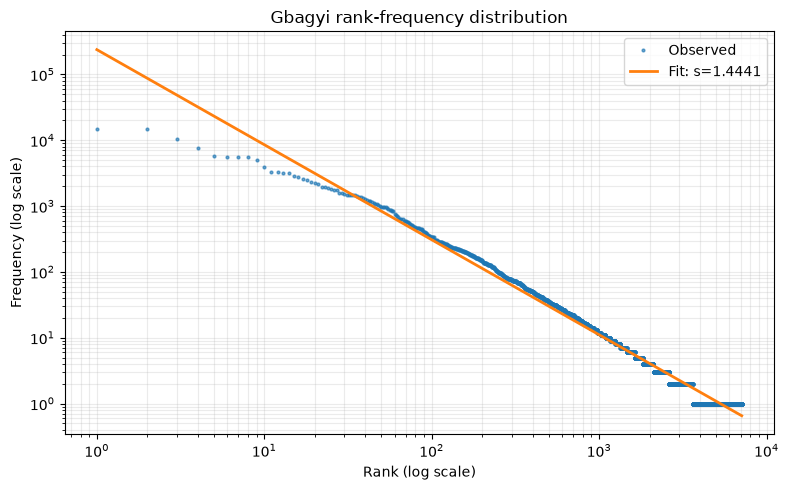

{'s': 1.444133315923019, 'C': 12.381894427578828, 'r2': 0.9764500818837777}


In [6]:
import matplotlib.pyplot as plt
import numpy as np

zipf_details = zipf_fit_details(frequency)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(zipf_details["ranks"], zipf_details["frequencies"], "o", markersize=2, alpha=0.65, label="Observed")
ax.loglog(
    zipf_details["ranks"],
    np.exp(zipf_details["C"]) * zipf_details["ranks"] ** (-zipf_details["s"]),
    linewidth=2,
    label=f'Fit: s={zipf_details["s"]:.4f}',
)
ax.set_xlabel("Rank (log scale)")
ax.set_ylabel("Frequency (log scale)")
ax.set_title("Gbagyi rank-frequency distribution")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig("submissions/group_06_gbagyi/zipf_plot.png", dpi=180)
plt.show()
print({"s": zipf_details["s"], "C": zipf_details["C"], "r2": zipf_details["r2"]})


In [7]:
print("Top 10 tokens:")
for rank, (token, count) in enumerate(frequency.most_common(10), start=1):
    print(rank, token, count)


Top 10 tokens:
1 , 15050
2 n 14613
3 . 10515
4 ɓa 7631
5 - 5798
6 zhin 5649
7 wo 5577
8 yi 5497
9 wa 5108
10 nu 3912


The Gbagyi orthography contains characters such as `ɓ` and may contain subdots or combining tone marks in source material. NFC normalization prevents canonically equivalent spellings from being counted as unrelated strings, while retaining the actual diacritics rather than stripping them. Diacritics can increase vocabulary size when they distinguish lexical or grammatical forms; inconsistent source orthography can have the opposite effect by fragmenting counts across spellings.


## Part 4 — Unigram/bigram model and perplexity

The model counts unigrams and adjacent within-sentence bigrams from scratch. Add-1 smoothing uses:

`P(w2 | w1) = (count(w1,w2) + 1) / (count(w1) + V)`

The unseen test file is evaluated directly, without hard-coding its score.


In [8]:
model = BigramModel()
bigram_tokens = model.fit(PROCESSED_PATH)
perplexity = model.compute_perplexity("tests/test_gbagyi_unseen.txt")
print({
    "unigram_tokens": sum(model.unigrams.values()),
    "vocabulary": model.vocab_size,
    "bigram_types": len(model.bigrams),
    "bigram_tokens": bigram_tokens,
    "perplexity": perplexity,
})
assert math.isfinite(perplexity) and perplexity > 0


{'unigram_tokens': 246570, 'vocabulary': 7105, 'bigram_types': 59226, 'bigram_tokens': 238612, 'perplexity': 795.9988326136164}


In [9]:
print("Top observed bigrams:")
for (w1, w2), count in model.bigrams.most_common(10):
    print((w1, w2), count, model.get_probability(w1, w2))


Top observed bigrams:
('n', 'na') 1310 0.0603646744635786
('ge', ',') 1272 0.12177157069064473
(',', '“') 1263 0.057052584066802074
(',', 'n') 1238 0.055924170616113746
('n', 'wo') 1057 0.04871535132148448
('.', '”') 1038 0.058967082860385926
('n', 'ɓa') 805 0.037112072934892715
('yi', ',') 802 0.06372004443739089
(',', 'wa') 797 0.03601895734597156
('m', '.') 791 0.09388335704125178


## Reproducibility and integrity notes

- The raw JSONL records preserve source URL and retrieval date for every verse.
- The data is fetched directly from the public STEP Bible chapter pages by the submitted `requests` code.
- No pre-tokenized third-party dataset is used.
- The final group report must be updated with the real member names, student IDs, emails, and only the contributions represented by their own Git history.
- The team lead must review all changes and the GitHub Actions/autograder results before opening the final PR.
